(Unsupervised) Credit Card Agency - Clustering 
Project Statement

Goal is to ingest data about credit card users in order to predict groups of users. 

 

Task 1: EDA 

Input Dataset: CC_GENERAL.csvLinks to an external site.

Explore the Data: 
Make informative plots
Take note of interesting outcomes
Think statistically about the data
 

Task 2: Clustering

Research and Apply at least two different clustering algorithms from Sklearn: 
Include your reasoning for trying a specific clustering algo
NOTE: If your algorithm depends on distance for clustering, then you will need to scale your data before making predictions.
Make sure to include silhouette scores your models and numbers of clusters.
 

Task 3: Visualize Clusters via Dimensionality Reduction

Try the following Dimensionality Reduction Techniques in order to make a 2D graph with your data and your Models' predicted labels: 
NOTE: Make sure to exclude the cluster labels from the data when calling .fit()
PCA
Feature Agglomeration
t-SNE
TruncatedSVD
 

Task 4: Supervised Learning

Research and Apply the best Supervised Learning Technique you can find 
Choose the best type of model for this data (Regression vs Classification)
Either you or your model needs to handle imbalanced target counts
Use Cross Validation on your model training
Score the model's predictions
Make sure you are choosing an appropriate metric for scoring
Convince me that you chose the correct metric
Conduct hyper-parameter tuning
Train a final model that uses the best hyper-parameters and all available data. (Great time to practice Pipelines)
Input: Data in the shape of the original .CSV file
Output: Prediction of a Class
 

Task 5: Reporting

Create a markdown report. Include: 
Actions completed
Interesting Observations
Which Clustering Algorithm worked the best
Why?
Which Dimensionality Reduction Techniques you used / preferred
Why?
Summarize the Supervised Learning Process
Which Algorithm?
Regression or Classification?
How did you handle the potential for overfitting?
How did you score your models?

In [6]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import KNNImputer
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, AffinityPropagation, SpectralClustering, OPTICS, Birch
from sklearn.decomposition import PCA, TruncatedSVD, NMF
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler


In [7]:
#read in the csv and create dataframe
data = pd.read_csv('CC_GENERAL.csv')

#describe pd and fix dtypes
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [8]:
#print out null values in MINIMUM_PAYMENTS and CREDIT_LIMIT
print(data[['MINIMUM_PAYMENTS', 'CREDIT_LIMIT']].isnull().sum())

#print all MINIMUM_PAYMENTS with a value of zero
pd_zero = data[data['MINIMUM_PAYMENTS'] == 0]

#Fill null values with zero since zero is a valid min payment
data['MINIMUM_PAYMENTS'].fillna(0, inplace=True)

#print line with credit limit value null
data[data['CREDIT_LIMIT'].isnull()]

#fill null value credit limit with KNN imputer
imputer = KNNImputer(n_neighbors=5)
data[['CREDIT_LIMIT']] = imputer.fit_transform(data[['CREDIT_LIMIT']])
print(data.info())

# Drop CUST_ID as it is not needed for clustering and we can use inherent order of the dataframe to accomplish the same goal
data.drop('CUST_ID', axis=1, inplace=True)

# Reduce all data types to smallest necessary dtype to save memory
for col in data.select_dtypes(include=['float64']).columns:
    data[col] = pd.to_numeric(data[col], downcast='float')
for col in data.select_dtypes(include=['int64']).columns:
    data[col] = pd.to_numeric(data[col], downcast='integer')
print(data.info())

MINIMUM_PAYMENTS    313
CREDIT_LIMIT          1
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADV

### Notes so far ###
- MINIMUM_PAYMENTS had valid values of 0 for many entries and the NaNs could then be assumed to be zero as well.
   - This can be revised later and imputed if required, but seems to be an alirght assumption currently based on the similar low balance and payments needed.
   - It could also be something like a promotion of "No monthly payments for 6 months!" or similar which may not register a monthly payment when setting up the account.
- CREDIT_LIMIT on the other hand, only had one null value in the dataframe and no values that were 0.
   - This made it a much better candidate for the KNN imputer since even a slight mistake in imputation has a low chance of affecting too much.
- Reducing size of the dtypes seems to get more and more important as we move closer to real life amounts of data
   - It may not be overly helpful currently, but I would rather get into a good habit than to not think about it and skip over it in the future.
- CUST_ID is not inherently that meaningful as it can be represented by the row id inherent to the dataframe

## Future Plans ##
### Clustering the Data ###
- I am going to cluster and plot the data using all the reviewed clustering algorithms (and maybe a couple others we didn't see in class).
   - This will allow me to visually compare all the differing clusters and pick the best looking clusters of data

In [9]:
#Stop this cell from running automatically, comment if you want to run it
#%%script false --no-raise-error
# Create a function to cluster the data using different algorithms and plot them
def cluster_and_plot(data, algo, **kwargs):
   # Standardize the data
   scaler = MinMaxScaler()
   data_scaled = scaler.fit_transform(data)

   # Dimensionality reduction using multiple techniques
   pca = PCA(n_components=2)
   data_pca = pca.fit_transform(data_scaled)
   tsne = TSNE(n_components=2, random_state=42)
   data_tsne = tsne.fit_transform(data_scaled)
   svd = TruncatedSVD(n_components=2, random_state=42)
   data_svd = svd.fit_transform(data_scaled)
   nmf = NMF(n_components=2, random_state=42, max_iter=500)
   data_nmf = nmf.fit_transform(data_scaled)
    
    
   # Apply clustering algorithm
   if algo == 'kmeans':
      model = KMeans(**kwargs)
   elif algo == 'agglomerative':
      model = AgglomerativeClustering(**kwargs)
   elif algo == 'dbscan':
      model = DBSCAN(**kwargs)
   elif algo == 'affinity':
      model = AffinityPropagation(**kwargs)
   elif algo == 'spectral':
      model = SpectralClustering(**kwargs)
   elif algo == 'optics':
      model = OPTICS(**kwargs)
   elif algo == 'birch':
      model = Birch(**kwargs)
   else:
      raise ValueError("Unsupported algorithm")

   labels = model.fit_predict(data_scaled)

   # Plotting the different dimensionality reductions side by side
   # Add titles and legends to each plot
   fig, axes = plt.subplots(1, 4, figsize=(24, 5))
   axes[0].scatter(data_pca[:, 0], data_pca[:, 1], c=labels, cmap='viridis', s=10)
   axes[0].set_title(f'PCA Visualization with {algo.capitalize()} clustering')
   axes[1].scatter(data_tsne[:, 0], data_tsne[:, 1], c=labels, cmap='viridis', s=10)
   axes[1].set_title(f't-SNE Visualization with {algo.capitalize()} clustering')
   axes[2].scatter(data_svd[:, 0], data_svd[:, 1], c=labels, cmap='viridis', s=10)
   axes[2].set_title(f'SVD Visualization with {algo.capitalize()} clustering')
   axes[3].scatter(data_nmf[:, 0], data_nmf[:, 1], c=labels, cmap='viridis', s=10)
   axes[3].set_title(f'NMF Visualization with {algo.capitalize()} clustering')
   # Add a legend and labels for all plots' axes
   for ax in axes:
      ax.set_xlabel('Component 1')
      ax.set_ylabel('Component 2')
      ax.legend(*ax.collections[0].legend_elements(), title="Clusters")
      
      
      
   plt.show()

   # Calculate silhouette score
   if len(set(labels)) > 1:
      score = silhouette_score(data_scaled, labels)
      print(f'Silhouette Score for {algo.capitalize()}: {score}')
      print(f'Number of clusters: {len(set(labels))}')
   else:
      print(f'Only one cluster found for {algo.capitalize()}, silhouette score not applicable.')

In [10]:
#Stop this cell from running automatically, comment if you want to run it
#%%script false --no-raise-error
# Use all clustering algorithms on the data and compare silhouette scores
# Create a dictionary of algorithms and their parameters
algorithms = {'kmeans': {'n_clusters': 5, 'random_state': 42},
              'agglomerative': {'n_clusters': 5},
              'dbscan': {'eps': 0.1, 'min_samples': 5},
            #   'affinity': {'damping': 0.5, 'max_iter': 10, 'convergence_iter': 5, 'preference': 0.9},
            #   'spectral': {'n_clusters': 5, 'random_state': 42},
              'optics': {'min_samples': 5, 'xi': 0.05, 'min_cluster_size': 5, 'n_jobs': -1, 'metric':'manhattan', 'max_eps': 0.3},
              'birch': {'n_clusters': 5, 'branching_factor': 60, 'threshold': 0.5}}
# for algo, params in algorithms.items():
    # cluster_and_plot(data, algo, **params)


### Results Reporting ###
- t-SNE seems to have the best visual separation of clusters so far, so I will use that for the final reporting of clusters.
    - I want to tweak the t-SNE value a bit more to see if I can get better resolution of clusters to allow the clustering alorith to better select clusters to be predicted.
- I also want to determine the best settings for the clustering algos so we get the best representation of the data.
   - Cross validation should be a decent way to tweak the hyperparameters of the clustering algos to get the best silhouette scores possible.

In [11]:
# Prepare Cross Validation for Hyperparameter Tuning
# create a parameter grid for different algorithms
kmeans_param_grid = {
    'n_clusters': [3, 5, 7, 10],}
agg_param_grid = {
    'n_clusters': [3, 5, 7, 10],
    'linkage': ['ward', 'complete', 'average', 'single'],
    'metric': ['euclidean', 'manhattan', 'cosine', 'l1', 'l2']}
dbscan_param_grid = {
    'eps': [0.05, 0.1, 0.2],
    'min_samples': [3, 5, 10]}
optics_param_grid = {
    'min_samples': [3, 5, 10],
    'xi': [0.03, 0.05, 0.1],
    'min_cluster_size': [3, 5, 7],
    'metric': ['euclidean', 'manhattan'],
    'max_eps': [0.2, 0.3, 0.5],
    'n_jobs': [-1]}
birch_param_grid = {
    'n_clusters': [3, 5, 7, 10],
    'branching_factor': [30, 50, 70],
    'threshold': [0.3, 0.5, 0.7]}
# Combine all parameter grids into a dictionary
param_grids = {
    'kmeans': kmeans_param_grid,
    'agglomerative': agg_param_grid,
    'dbscan': dbscan_param_grid,
    'optics': optics_param_grid,
    'birch': birch_param_grid
}
    

In [12]:
def cv_silhouette_scorer(estimator, X):
    cluster_labels = estimator.fit_predict(X)
    num_labels = len(set(cluster_labels))
    print(f'Cluster labels: {cluster_labels}')
    num_samples = len(X.index)
    print(f'Number of labels: {num_labels}, Number of samples: {num_samples}')
    if num_labels == 1 or num_labels == num_samples:
        return -1
    else:
        sc = silhouette_score(X, cluster_labels)
        print(f'Calculated silhouette score: {sc}')
        return sc

# Function to perform cross-validation for hyperparameter tuning
def cross_validate_clustering(data, algorithm, param_grid):
    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)
    data_scaled_df = pd.DataFrame(data_scaled, columns=scaler.feature_names_in_)
    best_score = -1
    best_params = None
    
    # Iterate through all parameter combinations
    print(f'Evaluating {algorithm} with parameters: {param_grid}')
    if algorithm == 'kmeans':
        print('Creating GridSearchCV for KMeans')
        model = GridSearchCV(KMeans(), param_grid=param_grid, scoring=cv_silhouette_scorer, cv=3, n_jobs=2, verbose=4)
    elif algorithm == 'agglomerative':
        print('Creating GridSearchCV for AgglomerativeClustering')
        model = GridSearchCV(AgglomerativeClustering(), param_grid=param_grid, scoring=cv_silhouette_scorer, cv=3, n_jobs=2, verbose=4)
    elif algorithm == 'dbscan':
        print('Creating GridSearchCV for DBSCAN')
        model = GridSearchCV(DBSCAN(), param_grid=param_grid, scoring=cv_silhouette_scorer, cv=3, n_jobs=2, verbose=4)
    elif algorithm == 'optics':
        print('Creating GridSearchCV for OPTICS')
        model = GridSearchCV(OPTICS(), param_grid=param_grid, scoring=cv_silhouette_scorer, cv=3, n_jobs=2, verbose=4)
    elif algorithm == 'birch':
        print('Creating GridSearchCV for Birch')
        model = GridSearchCV(Birch(), param_grid=param_grid, scoring=cv_silhouette_scorer, cv=3, n_jobs=2, verbose=4)
    else:
        raise ValueError("Unsupported algorithm")

    model.fit(data_scaled_df)
    score = model.best_score_
    if score > best_score:
        best_score = score
        best_params = model.best_params_
    print(f'Best Silhouette Score for {algorithm.capitalize()}: {best_score} with parameters: {best_params}')
    print(f'All results for each n_cluster search: {model.cv_results_}')
    return model

In [13]:
# Take all parameter grids and run cross validation
for algo, grid in param_grids.items():
        cross_validate_clustering(data, algo, grid)

Evaluating kmeans with parameters: {'n_clusters': [3, 5, 7, 10]}
Creating GridSearchCV for KMeans
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Silhouette Score for Kmeans: 0.36204435908498295 with parameters: {'n_clusters': 3}
All results for each n_cluster search: {'mean_fit_time': array([0.03985826, 0.01382152, 0.00924691, 0.01071803]), 'std_fit_time': array([0.02391524, 0.00426992, 0.00105095, 0.00189177]), 'mean_score_time': array([0.14490088, 0.13655734, 0.13385804, 0.13766829]), 'std_score_time': array([0.00310883, 0.0019801 , 0.00210391, 0.00420619]), 'param_n_clusters': masked_array(data=[3, 5, 7, 10],
             mask=[False, False, False, False],
       fill_value=999999), 'params': [{'n_clusters': 3}, {'n_clusters': 5}, {'n_clusters': 7}, {'n_clusters': 10}], 'split0_test_score': array([0.37228489, 0.32052775, 0.32494823, 0.2925346 ]), 'split1_test_score': array([0.38733188, 0.34713021, 0.32240328, 0.34813809]), 'split2_test_score': array([0.32651631, 0.

f:\AI and Machine Learning course\FSA_devops\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
48 fits failed out of a total of 240.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
12 fits failed with the following error:
Traceback (most recent call last):
  File "f:\AI and Machine Learning course\FSA_devops\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 857, in _fit_and_score
    estimator.fit(X_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "f:\AI and Machine Learning course\FSA_devops\.venv\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "f:\AI and Machine Learning course\FSA_devops\.venv

Best Silhouette Score for Agglomerative: 0.3639970250992937 with parameters: {'linkage': 'single', 'metric': 'euclidean', 'n_clusters': 3}
All results for each n_cluster search: {'mean_fit_time': array([1.11752121e+00, 1.06321263e+00, 1.17628264e+00, 1.09327173e+00,
       2.00136503e-03, 1.60519282e-03, 1.46365166e-03, 1.44497554e-03,
       1.78996722e-03, 1.52699153e-03, 1.38401985e-03, 1.95884705e-03,
       1.72964732e-03, 1.20337804e-03, 1.35731697e-03, 1.69905027e-03,
       1.38870875e-03, 1.27140681e-03, 1.40436490e-03, 1.47136052e-03,
       1.05879354e+00, 1.05833562e+00, 1.11734104e+00, 1.05960655e+00,
       1.11440969e+00, 1.05498958e+00, 1.05040161e+00, 1.06171815e+00,
       1.01729282e+00, 1.04471024e+00, 1.02650523e+00, 1.01002860e+00,
       1.04913489e+00, 1.05362558e+00, 1.04451172e+00, 1.06029948e+00,
       1.08398604e+00, 1.08437276e+00, 1.04457100e+00, 1.04345115e+00,
       1.08642491e+00, 1.09224073e+00, 1.10006285e+00, 1.08828306e+00,
       1.11635145e+00, 

In [14]:
# KMeans had the best score so I will rerun its grid search with more parameters
kmeans_param_grid_extended = {
    'n_clusters': [15],
    'init': ['k-means++', 'random'],
    'n_init': ['auto', 10, 20, 30],
    'algorithm': ['elkan', 'lloyd']
    }

grid_cv_res = cross_validate_clustering(data, 'kmeans', kmeans_param_grid_extended)

Evaluating kmeans with parameters: {'n_clusters': [15], 'init': ['k-means++', 'random'], 'n_init': ['auto', 10, 20, 30], 'algorithm': ['elkan', 'lloyd']}
Creating GridSearchCV for KMeans
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Silhouette Score for Kmeans: 0.30627304955892387 with parameters: {'algorithm': 'elkan', 'init': 'k-means++', 'n_clusters': 15, 'n_init': 30}
All results for each n_cluster search: {'mean_fit_time': array([0.02681589, 0.1936601 , 0.41378824, 0.59541527, 0.20958734,
       0.212545  , 0.44031167, 0.61195278, 0.01318192, 0.10594853,
       0.20651825, 0.2979718 , 0.07758856, 0.0698514 , 0.17122904,
       0.23004301]), 'std_fit_time': array([0.00074986, 0.0043525 , 0.05230474, 0.01556156, 0.03485244,
       0.01362225, 0.02229353, 0.02893696, 0.0022135 , 0.01133176,
       0.01563292, 0.02743427, 0.00672138, 0.00726345, 0.01249542,
       0.01712842]), 'mean_score_time': array([0.14919289, 0.24109435, 0.36608926, 0.48476076, 0.2394654 ,
  

### Results so far ###
- KMeans had the best silhouette score overall on the algos and the highest score was achieved with 2 clusters.
- However 4, 9, and 10 clusters also had decent silhouette scores and may be more useful for segmenting customers into more specific groups.
- Here are the best silhouette scores for KMeans with varying n_clusters after cross validation of hyperparameters:
    - Best Silhouette Score for Kmeans: 0.3922672271471111 with parameters: {'algorithm': 'lloyd', 'init': 'k-means++', 'n_clusters': 2, 'n_init': 'auto'}
    - Best Silhouette Score for Kmeans: 0.372384572409363 with parameters: {'algorithm': 'elkan', 'init': 'random', 'n_clusters': 3, 'n_init': 30}
    - Best Silhouette Score for Kmeans: 0.3454338466377833 with parameters: {'algorithm': 'elkan', 'init': 'k-means++', 'n_clusters': 4, 'n_init': 'auto'}
    - Best Silhouette Score for Kmeans: 0.326408981561538 with parameters: {'algorithm': 'elkan', 'init': 'random', 'n_clusters': 5, 'n_init': 10}
    - Best Silhouette Score for Kmeans: 0.3302438523152338 with parameters: {'algorithm': 'elkan', 'init': 'random', 'n_clusters': 6, 'n_init': 30}
    - Best Silhouette Score for Kmeans: 0.32366782411012357 with parameters: {'algorithm': 'elkan', 'init': 'random', 'n_clusters': 7, 'n_init': 20}
    - Best Silhouette Score for Kmeans: 0.33608004294373633 with parameters: {'algorithm': 'lloyd', 'init': 'random', 'n_clusters': 8, 'n_init': 'auto'}
    - Best Silhouette Score for Kmeans: 0.3377783674069339 with parameters: {'algorithm': 'elkan', 'init': 'k-means++', 'n_clusters': 9, 'n_init': 30}
    - Best Silhouette Score for Kmeans: 0.34511660669368743 with parameters: {'algorithm': 'elkan', 'init': 'k-means++', 'n_clusters': 10, 'n_init': 30}




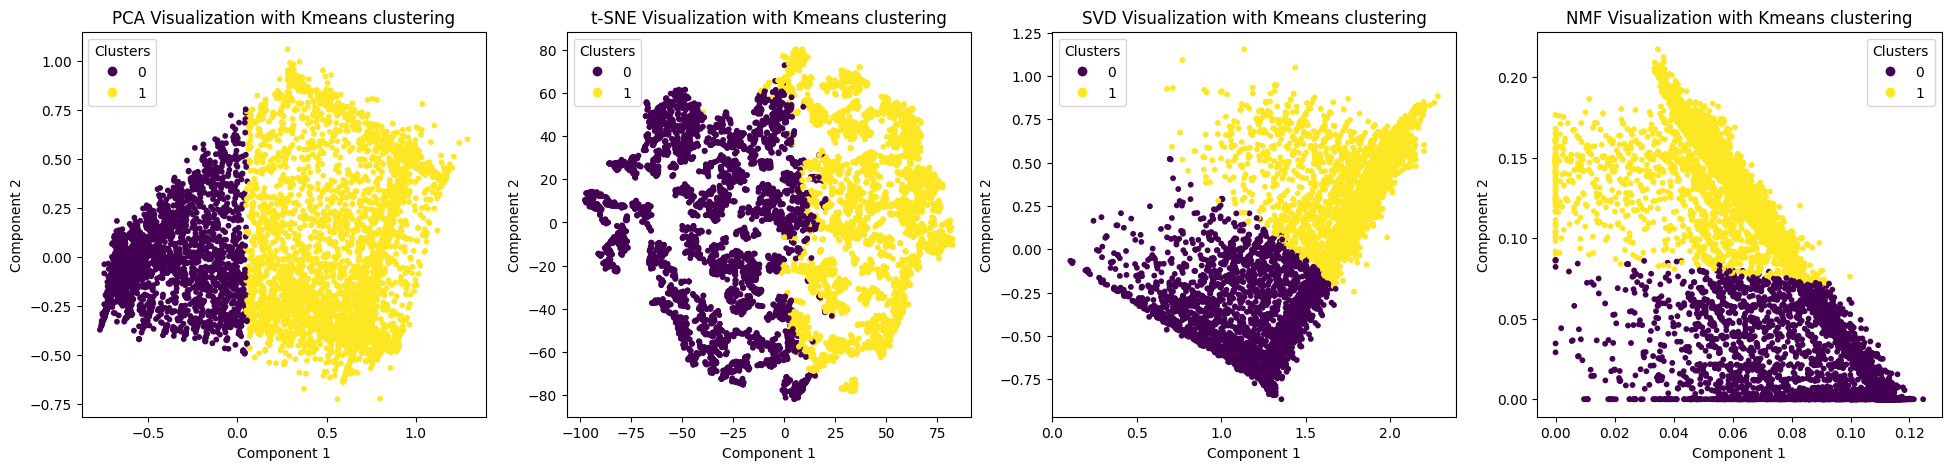

Silhouette Score for Kmeans: 0.38671943129663633
Number of clusters: 2


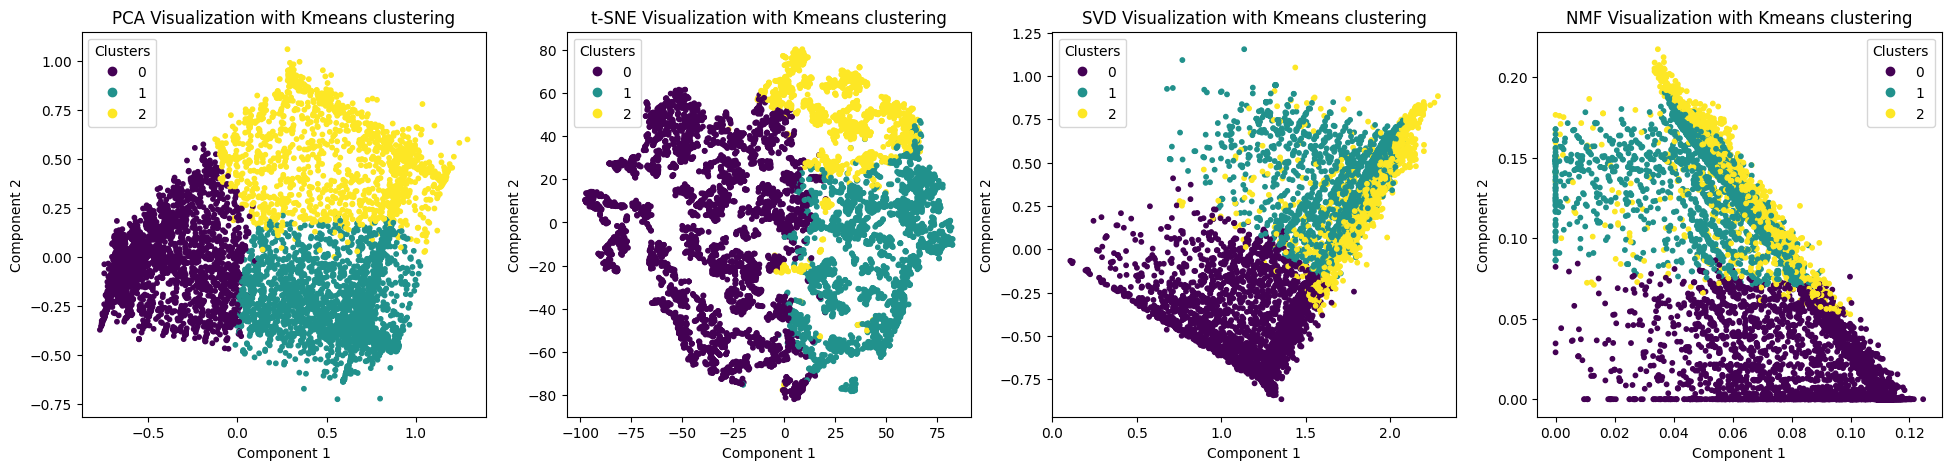

Silhouette Score for Kmeans: 0.37239217808178565
Number of clusters: 3


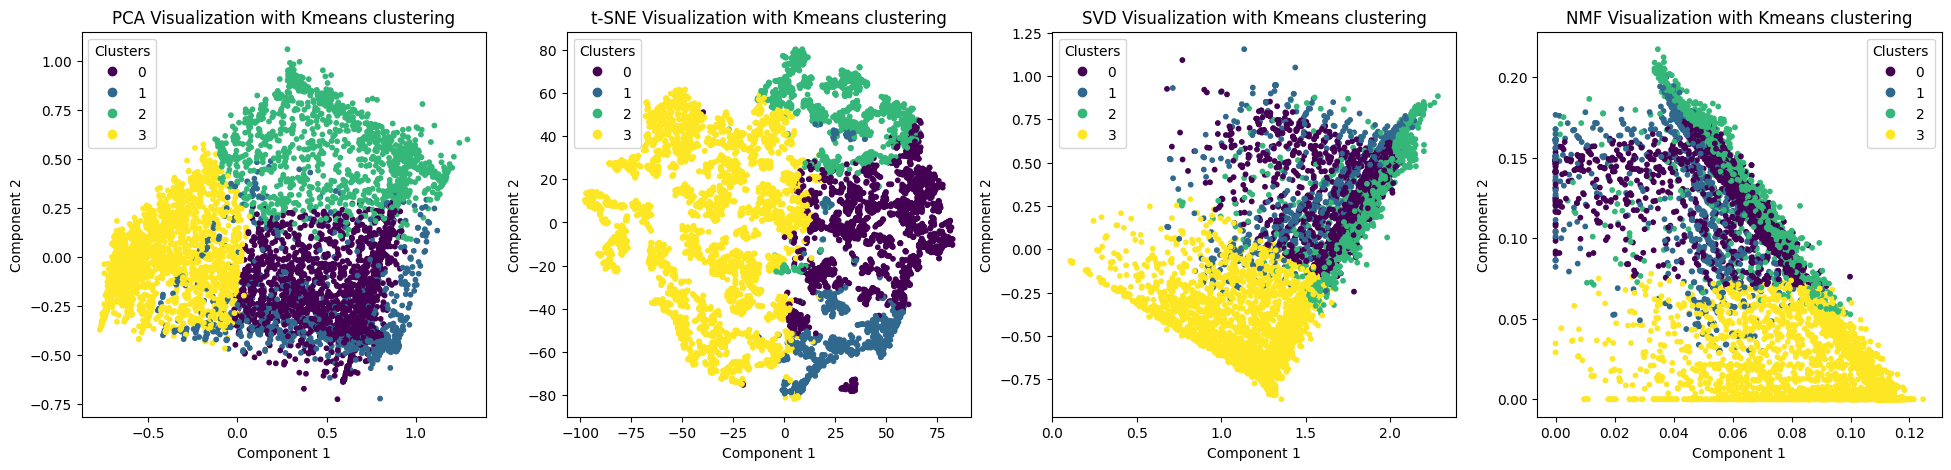

Silhouette Score for Kmeans: 0.3690780311807592
Number of clusters: 4


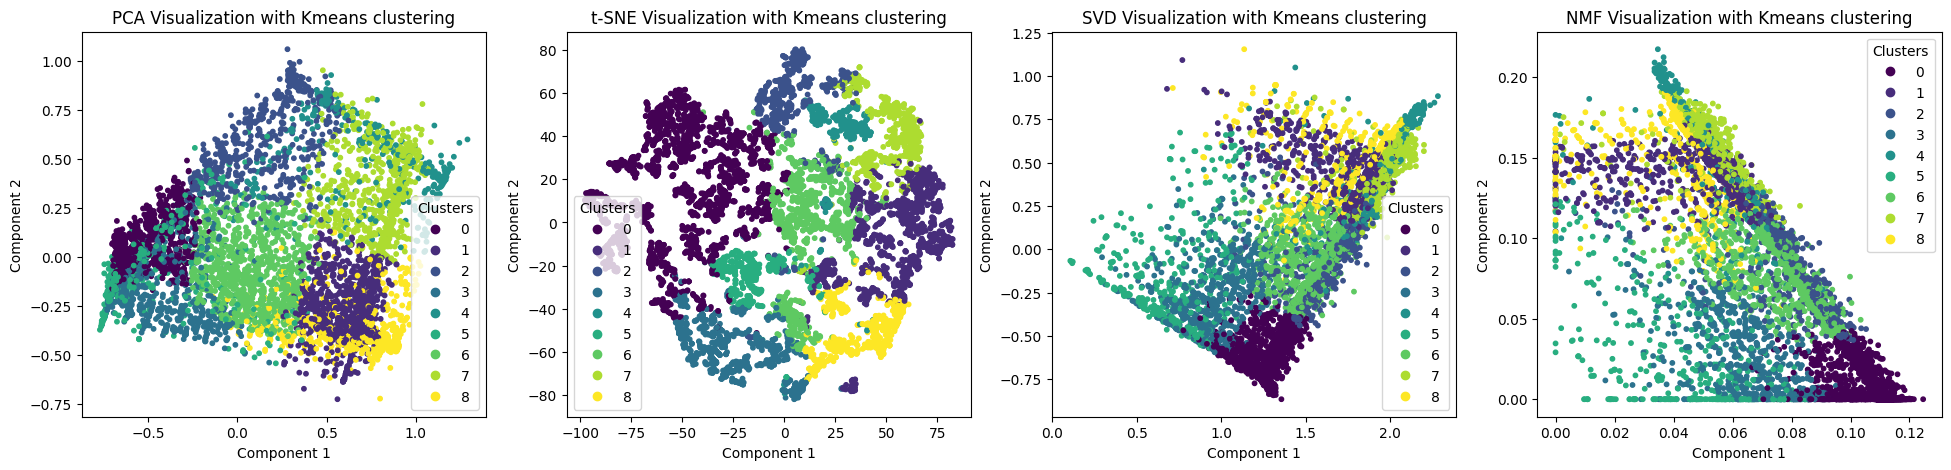

Silhouette Score for Kmeans: 0.3340554161028204
Number of clusters: 9


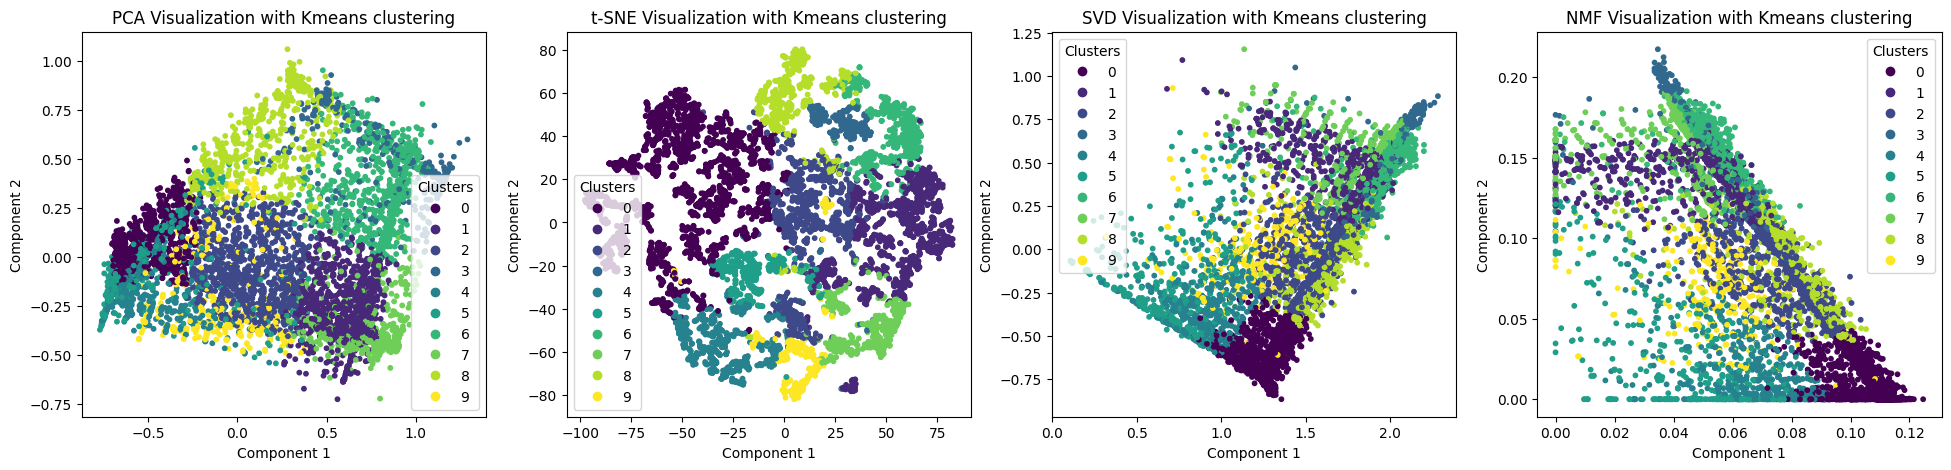

Silhouette Score for Kmeans: 0.3420050590167199
Number of clusters: 10


In [15]:
# Plot the t-SNE visualization for each of the highest scoring cluster amounts found above

all_args = [{'algorithm': 'lloyd', 'init': 'k-means++', 'n_clusters': 2, 'n_init': 'auto'},
            {'algorithm': 'elkan', 'init': 'random', 'n_clusters': 3, 'n_init': 30},
            {'algorithm': 'elkan', 'init': 'k-means++', 'n_clusters': 4, 'n_init': 'auto'},
            {'algorithm': 'elkan', 'init': 'k-means++', 'n_clusters': 9, 'n_init': 30},
            {'algorithm': 'elkan', 'init': 'k-means++', 'n_clusters': 10, 'n_init': 30}]

for args in all_args:
    cluster_and_plot(data, 'kmeans', **args)

### Results so far ###
- Plotting them out visually, the t-SNE shows a decent clustering around 10 clusters, with some overlap but decent separation.

- Will now move on to training a supervised learning model to predict cluster labels based on the features in the data.
    - Hopefully a few models can be trained quickly and accurately using the grid search again.

In [16]:
model = KMeans(algorithm='elkan', init='k-means++', n_clusters=10, n_init=30)
# Scale the data the same as before
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)
data_scaled_df = pd.DataFrame(data_scaled, columns=scaler.feature_names_in_)

labels = model.fit_predict(data_scaled_df)


In [17]:
%pip install xgboost

# We now have labels to act as our targets for supervised learning, they can be kept seperate to act as our y values.
# Now to try training some models to predict these labels from the features.
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
import xgboost as xgb

# Create parameter grids for each of these
random_forest_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
    }
hist_gb_param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'max_iter': [100, 200],
    'max_depth': [3, 5, 10]
    }
xgboost_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 10]
    }


Note: you may need to restart the kernel to use updated packages.


In [18]:
# Function to perform cross-validation for supervised models
def cross_validate_supervised(X, y, model, param_grid):
    # Create a custom scorer that prints out multiple metrics
    m_scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'roc_auc_ovr_weighted']
    
    grid_search = GridSearchCV(model, param_grid=param_grid, scoring=m_scoring, cv=5, n_jobs=-1, verbose=4, refit='accuracy')
    grid_search.fit(X, y)
    print(f'Best Accuracy Score: {grid_search.best_score_} with parameters: {grid_search.best_params_}')
    return grid_search

In [19]:
# Cross validate each model
rf_cv_res = cross_validate_supervised(data_scaled_df, labels, RandomForestClassifier(random_state=42), random_forest_param_grid)
hgb_cv_res = cross_validate_supervised(data_scaled_df, labels, HistGradientBoostingClassifier(random_state=42), hist_gb_param_grid)
xgb_cv_res = cross_validate_supervised(data_scaled_df, labels, xgb.XGBClassifier(random_state=42, eval_metric='mlogloss'), xgboost_param_grid)



Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Accuracy Score: 0.9791061452513967 with parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Accuracy Score: 0.9833519553072627 with parameters: {'learning_rate': 0.1, 'max_depth': 10, 'max_iter': 200}
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Accuracy Score: 0.9831284916201117 with parameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}


In [20]:
# compare results and pick best model
rf_best = (rf_cv_res.best_score_, rf_cv_res.best_params_, rf_cv_res.best_estimator_)
hgb_best = (hgb_cv_res.best_score_, hgb_cv_res.best_params_, hgb_cv_res.best_estimator_)
xgb_best = (xgb_cv_res.best_score_, xgb_cv_res.best_params_, xgb_cv_res.best_estimator_)

for score, params, model in [rf_best, hgb_best, xgb_best]:
    best_model = None
    best_score = -1.0
    best_params = None
    if score > best_score:
        best_score = score
        best_params = params
        best_model = model
    
print(f'Best Supervised Model: {best_model.__class__.__name__} Score: {best_score} with parameters: {best_params}')

Best Supervised Model: XGBClassifier Score: 0.9831284916201117 with parameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}


### Final Report ###
- In this notebook, I clustered the data using multiple differing algos to compare some basic results and visualizations.
- KMeans looked the best and the t-SNE provided the best visual separation of clusters.
- Using that I was able to hypertune the KMeans model to get the best clustering, in regards to not just silhouette score but also number of clusters.
- Using the cluster labels from KMeans, I was able to train multiple supervised learning models to predict the cluster labels from the features.
    - I used 3 different models (RandomForestClassifier, HistGradientBoostingClassifier, and XGBoostClassifier) and did cross validation with hyperparameter tuning to get the best results.
- I was also able to use multiple scoring metrics within the cross validation steps that I was able to refit over the accuracy metric to get a better picture overall of the models' performance.
- I was not able to build the pipeline at the end as I had run past time and wanted to submit what I had.
#### Observations ####
- All the clustering algorithms and visualizations were relatively unique and yet even when using t-SNE (which I had thought looked the best for visualization) you could see patterns of the same clusters in unique layouts in the other scatterplots.
    - Things like multiple lines sharing the same slant, but different origins, or slusters that were similarly shaped but shared a lot of overlap in the 2D space.
- The silohuette scores for the number of clusters were high at the very low ends (2 or 3 clusters) but that seemed to be because it was easy to draw lines through large masses in 2D space and pretend there was a relationship.
    - As the number of clusters increased, the scoresdropped but then would come back up slightly at certain intervals (4, 9, 10 clusters) which seemed to correspond to more natural groupings of the data.
    - This is easy to see once the t-SNE plots are visualized with the cluster labels added.
#### Best Clustering Algorithm ####
- KMeans
- Grouped the points best when viewed visually and had the best silhouette scores overall.
#### Best/Favorite Dimensionality Reduction Technique ####
- t-SNE
- Provided the best visual separation of clusters when plotted in 2D space.
- I found it the easiest to look at and pick apart the clusters as the algorithms's n_clusters amount was changed.
    - It was also the most visually appealing.
#### Best Supervised Learning Algorithm ####
- XGBoostClassifier
- Had the best accuracy score after cross validation and hyperparameter tuning.
- I chose classifiers over regressors since the cluster labels were categorical.
    - I think there may be some overfitting, but I was hoping that that the cross validation folding wouold help mitigate that.
    - I also kept the labels seperate from the features dataframe until the very end to help with that as well.
- I used multiple scoring metrics to get a better picture of the models' performance and refitted over accuracy since I wanted to use that metric as a baseline since most of the other types will affect the accuracy score.
- Overall I used accuracy to represent the final score as it is easiest to understand and explain.